# Generative Models

## Introduction

Generative modeling is the study of how to **learn a probability distribution** from data so that we can **generate new, realistic samples** that resemble the original dataset.  In other words, instead of just predicting or classifying, a generative model *creates* — images, audio, text, even video.

While most machine learning models are **discriminative** — trained to predict labels or estimate conditional probabilities such as $ p(y \mid x) $—**generative models** aim to learn the *underlying data distribution itself*, $ p(x) $.

Once a model learns this distribution, it can:
- **Sample** new, realistic examples $ x \sim p_\theta(x) $,
- **Estimate probabilities** or likelihoods for given inputs,
- **Interpolate** between examples in a learned latent space,
- And even **condition** on auxiliary information to perform tasks like text-to-image or text-to-audio generation.

Formally, the goal of a generative model is to approximate the *true data distribution* $ p_{\text{data}}(x) $ using a parameterized model $ p_\theta(x) $,  
such that
$$
p_\theta(x) \approx p_{\text{data}}(x).
$$

If we can accurately capture this underlying probability structure, then drawing new samples from $ p_\theta(x) $ should produce realistic and coherent data that looks like it came from the training distribution.

### Why Generative Modeling?

Generative models allow us to move beyond prediction to *creation*.  
They are capable of synthesizing entirely new data, filling in missing information, translating between domains, or serving as simulation engines for downstream systems.  

Some practical motivations:
- **Data Augmentation:** Creating synthetic training data to balance or expand datasets.
- **Representation Learning:** Learning compressed latent spaces that capture underlying structure.
- **Creative Tasks:** Text, image, and music generation.
- **Scientific Discovery:** Designing molecules, materials, and proteins that obey learned physical constraints.


### A Timeline

Over the past decade, the field has evolved dramatically. Early models like **Variational Autoencoders (VAEs)** and **Generative Adversarial Networks (GANs)** laid the groundwork for probabilistic and adversarial learning.  
These approaches focused on learning to represent data in a lower-dimensional latent space and then generate new data from it.

More recently, **Diffusion Models** and **Foundation Models** have transformed the landscape. Diffusion models achieve state-of-the-art fidelity through iterative denoising, while large multimodal foundation models like **Stable Diffusion**, **DALL-E 3**, and **Sora** combine language understanding with image, audio, and video generation.

| Era | Model Type | Key Idea | Example Models |
|-----|-------------|-----------|----------------|
| 2013-2015 | **Autoencoders / VAEs** | Learn probabilistic latent representations | VAE, β-VAE |
| 2014-2018 | **GANs** | Adversarial training between generator and discriminator | DCGAN, CycleGAN, StyleGAN |
| 2020-2023 | **Diffusion & Score-based Models** | Learn to reverse a noising process | DDPM, Stable Diffusion |
| 2023-Present | **Foundation / Multi-modal Models** | Unified architectures for text-image-audio generation | DALL-E 3, Sora, Gemini 1.5 Pro |

### Generative Modeling in Context

While each class of model differs in how it represents \( p(x) \), they share a unifying goal:  
> **To capture and reproduce the structure of the data-generating process.**

- **VAEs** model $ p(x, z) = p(z) p_\theta(x \mid z) $ and use variational inference to learn the latent variable $ z $.
- **GANs** define an implicit distribution via a generator $ G(z) $ that transforms noise into realistic samples.
- **Diffusion Models** learn to iteratively *denoise* random noise into structured data.
- **Foundation Models** scale these ideas to massive, multimodal datasets—where text, image, and audio interact.

## Latent Variable Models and Variational Autoencoders (VAEs)

High-dimensional data like images, audio, or text often appears complex on the surface — but in reality, much of it lies near a **lower-dimensional manifold**.  

Many real-world datasets—images, sounds, text—are **high-dimensional**, but they are generated by a much smaller set of *latent factors*, such as lighting, pose, emotion, or other hidden causes of variation.  

Generative models that exploit this idea are called **latent variable models**.

A **latent variable model** makes this idea explicit by assuming that each observed data point $x$ is generated from some unobserved latent variable $z$.

We express this assumption through a *joint distribution*:

$$
p_\theta(x, z) = p(z) \, p_\theta(x \mid z)
$$

Here:
- $p(z)$ is a **prior distribution** over latent variables. We usually choose something simple and well-behaved, like a standard normal distribution $\mathcal{N}(0, I)$.
- $p_\theta(x \mid z)$ is the **decoder** (or *generative network*) — a neural network that learns how to map latent variables back into the data space.
- Together, they define the model’s full generative process.

If we want to compute how likely a given data point $x$ is under this model, we would integrate out all possible latent variables:

$$
p_\theta(x) = \int p_\theta(x \mid z) \, p(z) \, dz
$$

However, this integral is **intractable** for most neural networks — it can’t be computed exactly because the function $p_\theta(x \mid z)$ is highly nonlinear.


### Variational Inference

To train the model, we need to somehow *approximate* the true posterior distribution $p_\theta(z \mid x)$ — that is, the probability of a latent code $z$ given the observed data $x$.  
Unfortunately, this posterior is also intractable because it depends on the same integral we can’t compute directly.

The workaround is to introduce another neural network — the **encoder** — which learns an *approximate posterior*:

$$
q_\phi(z \mid x)
$$

This encoder produces a distribution (usually Gaussian) that estimates what the true latent distribution should be for a given input.  

Intuitively:
- The encoder **compresses** the data $x$ into a latent representation $z$.
- The decoder **reconstructs** the data from that representation.

Our goal is then to make this approximate posterior $q_\phi(z \mid x)$ as close as possible to the true posterior $p_\theta(z \mid x)$ while still reconstructing the data well.


### The Evidence Lower Bound (ELBO)

Since directly maximizing $\log p_\theta(x)$ is impossible, we instead maximize a *lower bound* on it — called the **Evidence Lower Bound (ELBO)**:

$$
\log p_\theta(x) \geq 
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)] 
- D_{\text{KL}}(q_\phi(z \mid x) \, || \, p(z))
$$

This ELBO objective has two competing terms:

1. **Reconstruction term:**  
   $\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]$  
   Encourages the decoder to accurately reconstruct the input $x$ from its latent code $z$.  
   This is similar to a traditional autoencoder loss.

2. **Regularization term - KL Divergence:**  
   $D_{\text{KL}}(q_\phi(z \mid x) \, || \, p(z))$  
   Encourages the learned latent space to stay close to the prior distribution (usually $\mathcal{N}(0, I)$).  
   This prevents the encoder from memorizing data and forces it to learn a smooth, continuous representation.

When we train a Variational Autoencoder, we are *maximizing* this ELBO, or equivalently *minimizing* the negative of it — the **VAE loss**.


### The VAE Architecture

A Variational Autoencoder consists of three main components:

- **Encoder (Inference Network):**  
  Maps the input $x$ into two vectors — the mean $\mu_\phi(x)$ and variance $\sigma_\phi^2(x)$ — defining the approximate posterior $q_\phi(z \mid x) = \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x)I)$.

- **Reparameterization Trick:**  
  Sampling directly from $q_\phi(z \mid x)$ would break backpropagation, because sampling is a non-differentiable operation.  
  To fix this, we rewrite the sampling step as:  
  $z = \mu + \sigma \odot \epsilon$, where $\epsilon \sim \mathcal{N}(0, I)$.  
  This allows gradients to flow through $\mu$ and $\sigma$ during training.

- **Decoder (Generative Network):**  
  Takes a latent vector $z$ and outputs a reconstruction $\hat{x}$ — an approximation of the original input.

Together, these networks form a fully differentiable system that can be trained end-to-end with stochastic gradient descent.


### Training Intuition

The VAE learns to build a **structured latent space** — a continuous manifold where similar examples are close together.  
If we take a point $z$ from that space and feed it through the decoder, we get a meaningful sample in data space.

After training, we can:
1. **Encode** real samples to see their position in the latent space.
2. **Interpolate** between points in $z$ to smoothly transform one image into another.
3. **Generate** new examples by sampling $z \sim \mathcal{N}(0, I)$ and decoding it:

$$
\tilde{x} = p_\theta(x \mid z), \quad z \sim \mathcal{N}(0, I)
$$

This makes VAEs one of the first successful deep generative models — combining probabilistic modeling, continuous latent spaces, and differentiable learning in a single elegant framework.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

# Encoder network
class Encoder(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

    def forward(self, x):
        x = x.view(-1, 784)
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

# Decoder network
class Decoder(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, 400)
        self.fc_out = nn.Linear(400, 784)

    def forward(self, z):
        h = F.relu(self.fc1(z))
        x_hat = torch.sigmoid(self.fc_out(h))
        return x_hat.view(-1, 1, 28, 28)

# VAE class
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar

In [2]:
def loss_function(x_hat, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

vae = VAE(latent_dim=20).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

num_epochs = 5
vae.train()

for epoch in range(num_epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_hat, mu, logvar = vae(x)
        loss = loss_function(x_hat, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.4f}")


Epoch 1, Loss: 165.9521
Epoch 2, Loss: 121.8361
Epoch 3, Loss: 114.6162
Epoch 4, Loss: 111.6205
Epoch 5, Loss: 109.8530


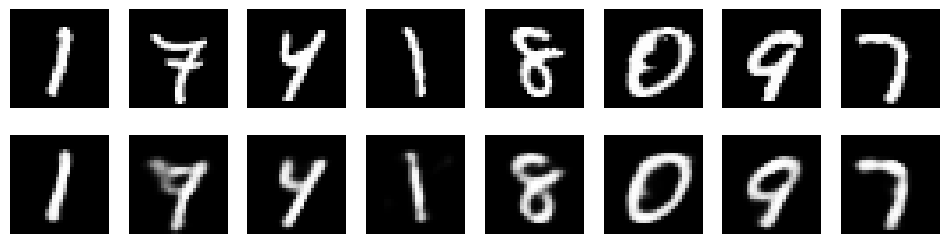

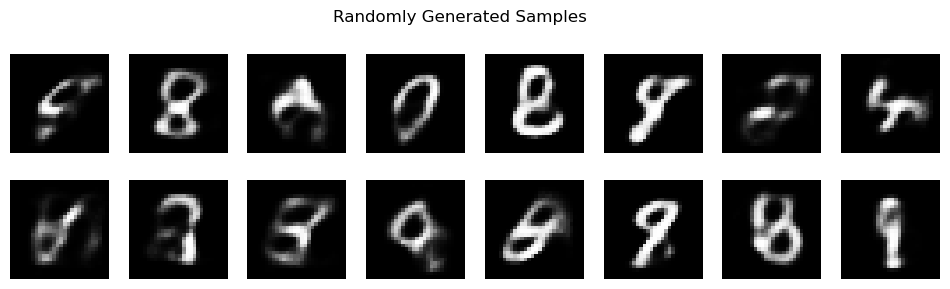

In [3]:
vae.eval()

# Get a batch
x, _ = next(iter(train_loader))
x = x.to(device)
with torch.no_grad():
    x_hat, _, _ = vae(x)
    # Generate from random latent samples
    z = torch.randn(16, 20).to(device)
    samples = vae.decoder(z)

# Plot originals vs reconstructions
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(x[i].cpu().squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_hat[i].cpu().squeeze(), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstruction")
plt.show()

# Plot random generations
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i].cpu().squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Randomly Generated Samples", y=1.02)
plt.show()

## Generative Adversarial Networks (GANs)

While Variational Autoencoders (VAEs) explicitly define and optimize a probability distribution over data,  
**Generative Adversarial Networks (GANs)** take an entirely different route.

A GAN does **not** attempt to compute or approximate $p_\theta(x)$ directly. Instead, it learns to **sample** from a distribution that *behaves* like the true data distribution $p_{\text{data}}(x)$ — without ever writing down its probability density. This is why GANs are often called **implicit generative models**: they can generate data but don’t define an explicit likelihood function.

### The Generator–Discriminator Game

A GAN is built from two neural networks that are trained **together** in an adversarial loop:

1. **Generator ($G$):**  
   The generator takes in a random noise vector $z \sim p_z(z)$—usually drawn from a simple prior such as a Gaussian or uniform distribution—and transforms it into a synthetic data sample:
   $$
   \tilde{x} = G(z)
   $$
   The generator’s goal is to produce samples that look *as if they came from the training data*.

2. **Discriminator ($D$):**  
   The discriminator takes in both real samples $x \sim p_{\text{data}}(x)$ and generated samples $\tilde{x} = G(z)$, and outputs a probability:
   $$
   D(x) \in [0, 1]
   $$
   indicating how likely the input is to be real.  
   It is essentially a binary classifier trained to distinguish between authentic data and synthetic data.

---

### The Adversarial Objective

The two networks play a **zero-sum game**:  
- The discriminator $D$ tries to **maximize** its accuracy at detecting fake samples.  
- The generator $G$ tries to **minimize** that same objective by fooling the discriminator.

The combined optimization is written as a minimax problem:

$$
\min_G \max_D \; V(D, G) =
\mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)] +
\mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$

Let’s unpack this:

- The first term rewards $D$ for correctly identifying real samples ($D(x)$ should be close to 1).  
- The second term rewards $D$ for correctly identifying fake samples ($D(G(z))$ should be close to 0).  
- Meanwhile, $G$ updates its weights to make $D(G(z))$ larger—pushing the discriminator toward making mistakes.

Over time, $G$ learns to produce data so realistic that $D$ can no longer distinguish fake from real.  
At this **Nash equilibrium**, the generator’s implicit distribution $p_G(x)$ becomes indistinguishable from the true data distribution $p_{\text{data}}(x)$.

---

### Training Dynamics

Training a GAN alternates between updating each network:

1. **Update the Discriminator ($D$):**  
   Freeze $G$ and optimize $D$ to correctly classify real vs. generated samples.  
   This means minimizing binary cross-entropy loss over real and fake data.

2. **Update the Generator ($G$):**  
   Freeze $D$ and update $G$ to maximize $D(G(z))$.  
   This step makes the generator produce outputs that are more likely to be classified as real.

Intuitively:
- The **discriminator** provides feedback—acting as a **learned loss function** for the generator.  
- The **generator** uses that signal to gradually align its output distribution with the real data.

However, this process can be **unstable**, since improvements in one model can temporarily destabilize the other.  
If $D$ becomes too strong, $G$’s gradients vanish.  
If $G$ dominates, $D$ provides no meaningful feedback.  
Balancing these updates is one of the core challenges in GAN training.

---

### Visualizing the Game Intuitively

You can think of the GAN training process as a **forger and detective** dynamic:
- The *forger* ($G$) learns to create convincing forgeries.
- The *detective* ($D$) learns to spot them.
- As both improve, they push each other toward perfection.

At convergence, the forgeries become indistinguishable from authentic data,  
and the detective can no longer tell them apart better than random guessing ($D(x) = 0.5$ for all $x$).

---

### Why GANs Were a Breakthrough

GANs were revolutionary because they proved that deep neural networks could **generate crisp, realistic images** without explicitly modeling data likelihoods.  
Instead, they learn purely through the feedback signal from another network.

They also inspired a huge family of variants:
- **DCGAN (2015):** Introduced convolutional architectures and batch normalization for stability.  
- **CycleGAN (2017):** Enabled unpaired image-to-image translation (e.g., turning horses into zebras).  
- **StyleGAN (2019–2021):** Achieved photorealistic face generation with controllable styles and latent directions.  

GANs remain a foundational pillar of generative modeling, influencing later diffusion and hybrid systems such as **VAE-GANs** and **adversarial diffusion models**.

---

### Key Takeaways

- GANs **implicitly** learn a data distribution by competing generator and discriminator networks.  
- The **discriminator** acts as a learned critic, replacing hand-designed reconstruction losses.  
- The **generator** learns to transform simple noise into structured, realistic data.  
- Challenges include training instability, vanishing gradients, and **mode collapse** (where $G$ produces limited sample diversity).  

In the next section, we’ll implement a simple GAN and visualize how a generator gradually learns to map random noise into recognizable digits.

---


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data setup
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

# Generator: maps noise -> image
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        x_hat = self.net(z)
        return x_hat.view(-1, 1, 28, 28)

# Discriminator: maps image -> probability (real/fake)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        return self.net(x)


In [ ]:
# Initialize models
latent_dim = 100
G = Generator(latent_dim).to(device)
D = Discriminator().to(device)

# Loss and optimizers
criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002)

num_epochs = 5
G.train(); D.train()

for epoch in range(num_epochs):
    for i, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Real and fake labels
        real = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        # -----------------
        # Train Discriminator
        # -----------------
        z = torch.randn(batch_size, latent_dim, device=device)
        fake_imgs = G(z).detach()

        real_loss = criterion(D(real_imgs), real)
        fake_loss = criterion(D(fake_imgs), fake)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # -----------------
        # Train Generator
        # -----------------
        z = torch.randn(batch_size, latent_dim, device=device)
        gen_imgs = G(z)
        g_loss = criterion(D(gen_imgs), real)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch {epoch+1} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


In [ ]:
G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = G(z).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i].squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Generated Samples (GAN)", y=1.02)
plt.show()
